# Self-Normalized Importance Sampling (SNIS) Example

This notebook demonstrates how to estimate the posterior expectation $\mathbb{E}[x \mid y]$ using **Self-Normalized Importance Sampling**.

### Target Posterior
The unnormalized posterior is given by:
$$
p(x \mid y) \propto \exp\left( -\frac{1}{2} x^2 - \frac{1}{2} (x^3 - y)^2 \right)
$$

We use a simple **proposal distribution** (which is also the prior):
$$
q(x) = \mathcal{N}(0, 1)
$$

---

### Step-by-Step Explanation of the Code

1. **Set parameters**  
   - `n = 1000`: Number of Monte Carlo samples  
   - `y = -2.325`: Observed data value  
   - `seed = 42`: For reproducibility

2. **Draw samples from the proposal**  
   Generate $x_i \sim \mathcal{N}(0, 1)$ for $i=1,\dots,n$.

3. **Compute log unnormalized weights**  
   $$
   v_i = -\frac{1}{2} \left( x_i^2 + (x_i^3 - y)^2 \right)
   $$

4. **Numerical stability (centering)**  
   Compute the mean $\mu_v = \frac{1}{n}\sum v_i$ and subtract it:
   $$
   \tilde{v}_i = v_i - \mu_v
   $$

5. **Exponentiate to get unnormalized weights**  
   $$
   \hat{w}_i = \exp(\tilde{v}_i)
   $$

6. **Normalize the weights**  
   $$
   w_i = \frac{\hat{w}_i}{\sum_{j=1}^n \hat{w}_j}
   $$

7. **Compute the self-normalized importance sampling estimate**  
   $$
   \mathbb{E}[x \mid y] \approx \sum_{i=1}^n w_i \, x_i
   $$

8. **Comparison with unweighted mean** (i.e., prior mean $\approx 0$)

9. **Visualization**  
   - Green histogram: Proposal distribution $q(x)$  
   - Orange histogram: Weighted samples approximating the target posterior $p(x \mid y)$

---

### Python Implementation

The following code cell implements the above steps:

Estimated posterior mean E[x|y]: -0.68
Unweighted (prior) mean: 0.01933


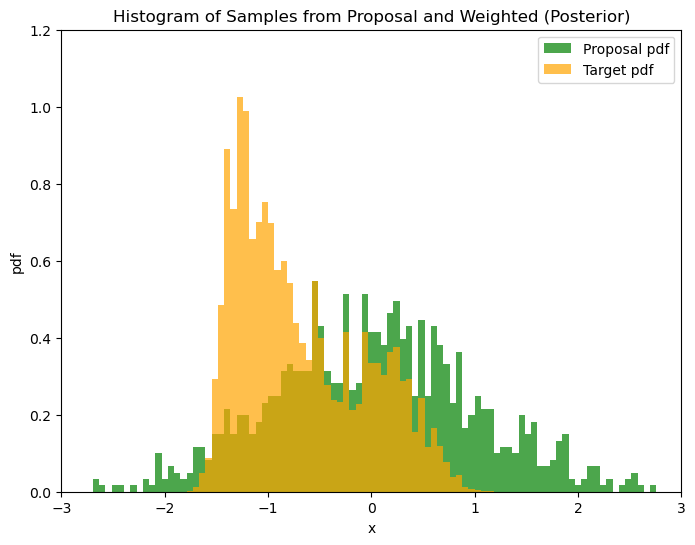

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set parameters as per the example
n = 1000  # Number of samples
y = -2.325   # Data value chosen to match approximate posterior mean of -0.69
seed = 42    # Seed for reproducibility (unweighted mean will be approx -0.0016)

# Step 1: Draw samples xi from the proposal distribution q(x) = N(0, 1)
np.random.seed(seed)
xi = np.random.normal(0, 1, n)

# Step 2: Compute the log unnormalized weights v_i = -0.5 * (x_i^2 + (x_i^3 - y)^2)
# This is proportional to log(p(x_i|y)) since constants are ignored
vi = -0.5 * (xi**2 + (xi**3 - y)**2)

# Step 3: Compute average mu_v for numerical stability (as described in the document)
mu_v = np.mean(vi)

# Step 4: Adjust vi to get ~vi = vi - mu_v
tilde_vi = vi - mu_v

# Step 5: Compute unnormalized weights hat_wi = exp(~vi)
hat_wi = np.exp(tilde_vi)

# Step 6: Normalize weights wi = hat_wi / sum(hat_wj)
sum_hat_w = np.sum(hat_wi)
wi = hat_wi / sum_hat_w

# Step 7: Compute the self-normalized importance sampling estimate of E[x|y]
posterior_mean = np.sum(xi * wi)

# Step 8: Compute the unweighted mean (prior mean, approx 0)
unweighted_mean = np.mean(xi)

# Print results (document has posterior approx -0.69, unweighted 4.2e-5; values may vary slightly with seed)
print(f"Estimated posterior mean E[x|y]: {posterior_mean:.2f}")
print(f"Unweighted (prior) mean: {unweighted_mean:.5f}")

# Step 9: Plot histograms as in Figure 4.3
# Histogram of unweighted samples (proposal pdf, green)
# Weighted histogram (target posterior pdf, orange)
bins = np.linspace(-3, 3, 100)  # Bins matching the document's x range -3 to 3
plt.figure(figsize=(8, 6))
plt.hist(xi, bins=bins, density=True, color='green', alpha=0.7, label='Proposal pdf')
plt.hist(xi, bins=bins, weights=wi, density=True, color='orange', alpha=0.7, label='Target pdf')
plt.xlim(-3, 3)
plt.ylim(0, 1.2)
plt.xlabel('x')
plt.ylabel('pdf')
plt.legend()
plt.title('Histogram of Samples from Proposal and Weighted (Posterior)')
plt.show()